In [1]:
# "Tour Guide" travel company has to analyze the customers' data and information to provide recommendations to the Policy Maker and Marketing Team and also build a model to predict the potential customer who is going to purchase the newly introduced travel package.
#To predict which customer is more likely to purchase the newly introduced travel package.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
import scipy.stats as stats
from sklearn import metrics
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')


In [3]:
!git clone https://github.com/bharatduggal/ENGG680_2025_Fall.git

Cloning into 'ENGG680_2025_Fall'...
remote: Enumerating objects: 243, done.
remote: Total 243 (delta 0), reused 0 (delta 0), pack-reused 243 (from 2)
Receiving objects: 100% (243/243), 24.72 MiB | 10.83 MiB/s, done.
Resolving deltas: 100% (107/107), done.


In [4]:
dataset = '/content/ENGG680_2025_Fall/Final Project/Tourism.xlsx'


In [5]:
#Reading the data

In [6]:
Tourism = pd.read_excel(dataset,sheet_name="Tourism")

In [7]:
Tourism

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0


In [8]:
tourism_copy=Tourism.copy()# copying the dataframe to the variable tourism_copy

In [9]:
tourism_copy.head()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
0,200000,1,41.0,Self Enquiry,3,6.0,Salaried,Female,3,3.0,Deluxe,3.0,Single,1.0,1,2,1,0.0,Manager,20993.0
1,200001,0,49.0,Company Invited,1,14.0,Salaried,Male,3,4.0,Deluxe,4.0,Divorced,2.0,0,3,1,2.0,Manager,20130.0
2,200002,1,37.0,Self Enquiry,1,8.0,Free Lancer,Male,3,4.0,Basic,3.0,Single,7.0,1,3,0,0.0,Executive,17090.0
3,200003,0,33.0,Company Invited,1,9.0,Salaried,Female,2,3.0,Basic,3.0,Divorced,2.0,1,5,1,1.0,Executive,17909.0
4,200004,0,NaN,Self Enquiry,1,8.0,Small Business,Male,2,3.0,Basic,4.0,Divorced,1.0,0,5,1,0.0,Executive,18468.0


In [10]:
tourism_copy.tail()

,CustomerID,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Occupation,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,PreferredPropertyStar,MaritalStatus,NumberOfTrips,Passport,PitchSatisfactionScore,OwnCar,NumberOfChildrenVisiting,Designation,MonthlyIncome
4883,204883,1,49.0,Self Enquiry,3,9.0,Small Business,Male,3,5.0,Deluxe,4.0,Unmarried,2.0,1,1,1,1.0,Manager,26576.0
4884,204884,1,28.0,Company Invited,1,31.0,Salaried,Male,4,5.0,Basic,3.0,Single,3.0,1,3,1,2.0,Executive,21212.0
4885,204885,1,52.0,Self Enquiry,3,17.0,Salaried,Female,4,4.0,Standard,4.0,Married,7.0,0,1,1,3.0,Senior Manager,31820.0
4886,204886,1,19.0,Self Enquiry,3,16.0,Small Business,Male,3,4.0,Basic,3.0,Single,3.0,0,5,0,2.0,Executive,20289.0
4887,204887,1,36.0,Self Enquiry,1,14.0,Salaried,Male,4,4.0,Basic,4.0,Unmarried,3.0,1,3,1,2.0,Executive,24041.0


In [11]:
tourism_copy.shape # inorder to find the shape of the data ie the number of rows and columns

(4888, 20)

In [12]:
tourism_copy.info()# to get the information of the data including the type of each field

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CustomerID                4888 non-null   int64  
 1   ProdTaken                 4888 non-null   int64  
 2   Age                       4662 non-null   float64
 3   TypeofContact             4863 non-null   object 
 4   CityTier                  4888 non-null   int64  
 5   DurationOfPitch           4637 non-null   float64
 6   Occupation                4888 non-null   object 
 7   Gender                    4888 non-null   object 
 8   NumberOfPersonVisiting    4888 non-null   int64  
 9   NumberOfFollowups         4843 non-null   float64
 10  ProductPitched            4888 non-null   object 
 11  PreferredPropertyStar     4862 non-null   float64
 12  MaritalStatus             4888 non-null   object 
 13  NumberOfTrips             4748 non-null   float64
 14  Passport

In [13]:
# there is no null values in the dataset
# fields such as type of contract,occupation,gender,ProductPitched,MaritalStatus,designation are categorical fields

In [14]:
col_object=tourism_copy.select_dtypes(['object'])# finding columns with object type
col_object.columns

Index(['TypeofContact', 'Occupation', 'Gender', 'ProductPitched',
       'MaritalStatus', 'Designation'],
      dtype='object')

In [15]:
for i in col_object.columns:
    tourism_copy[i]=tourism_copy[i].astype('category')# converting object type into categorical one inorder to reduce memory usage

In [16]:
tourism_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4888 entries, 0 to 4887
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   CustomerID                4888 non-null   int64   
 1   ProdTaken                 4888 non-null   int64   
 2   Age                       4662 non-null   float64 
 3   TypeofContact             4863 non-null   category
 4   CityTier                  4888 non-null   int64   
 5   DurationOfPitch           4637 non-null   float64 
 6   Occupation                4888 non-null   category
 7   Gender                    4888 non-null   category
 8   NumberOfPersonVisiting    4888 non-null   int64   
 9   NumberOfFollowups         4843 non-null   float64 
 10  ProductPitched            4888 non-null   category
 11  PreferredPropertyStar     4862 non-null   float64 
 12  MaritalStatus             4888 non-null   category
 13  NumberOfTrips             4748 non-null   float6

In [17]:
tourism_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4888.0,202443.500000,1411.188388,200000.0,201221.75,202443.5,203665.25,204887.0
ProdTaken,4888.0,0.188216,0.390925,0.0,0.00,0.0,0.00,1.0
Age,4662.0,37.622265,9.316387,18.0,31.00,36.0,44.00,61.0
CityTier,4888.0,1.654255,0.916583,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4637.0,15.490835,8.519643,5.0,9.00,13.0,20.00,127.0
NumberOfPersonVisiting,4888.0,2.905074,0.724891,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4843.0,3.708445,1.002509,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4862.0,3.581037,0.798009,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4748.0,3.236521,1.849019,1.0,2.00,3.0,4.00,22.0
Passport,4888.0,0.290917,0.454232,0.0,0.00,0.0,1.00,1.0


In [18]:
# minimum age of the customer is 18 and maximum age is 61 .There is missing values in the age column
#Duration of pitch is minimum 5 mins and maximum 127 minutes and mean is 15.49 minutes.there is missing values in this field
#NumberOfPersonVisiting is min 1 and max 5
#NumberOfFollowups is min 1 and max 6 .There is missing values
#Pitch Satisfaction Score is mean 3,minimum 1and maximum 5
#numberoftrips is max 22 and min 1,missing values are there
# monthly income is max 98678 ,min= 1000 and mean is 22347

In [19]:
tourism_copy['Age'].fillna(method='ffill',inplace=True)
tourism_copy['DurationOfPitch'].fillna(method='ffill',inplace=True)
tourism_copy['NumberOfFollowups'].fillna(method='ffill',inplace=True)
tourism_copy['NumberOfTrips'].fillna(method='ffill',inplace=True)
tourism_copy['NumberOfChildrenVisiting'].fillna(method='ffill',inplace=True)
tourism_copy['MonthlyIncome'].fillna(method='ffill',inplace=True)

In [20]:
tourism_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,4888.0,202443.500000,1411.188388,200000.0,201221.75,202443.5,203665.25,204887.0
ProdTaken,4888.0,0.188216,0.390925,0.0,0.00,0.0,0.00,1.0
Age,4888.0,37.584697,9.297737,18.0,31.00,36.0,44.00,61.0
CityTier,4888.0,1.654255,0.916583,1.0,1.00,1.0,3.00,3.0
DurationOfPitch,4888.0,15.443331,8.479713,5.0,9.00,13.0,20.00,127.0
NumberOfPersonVisiting,4888.0,2.905074,0.724891,1.0,2.00,3.0,3.00,5.0
NumberOfFollowups,4888.0,3.706628,1.000031,1.0,3.00,4.0,4.00,6.0
PreferredPropertyStar,4862.0,3.581037,0.798009,3.0,3.00,3.0,4.00,5.0
NumberOfTrips,4888.0,3.254910,1.852798,1.0,2.00,3.0,4.00,22.0
Passport,4888.0,0.290917,0.454232,0.0,0.00,0.0,1.00,1.0


In [21]:
tourism_copy.describe(include=['category']).T

,count,unique,top,freq
TypeofContact,4863,2,Self Enquiry,3444
Occupation,4888,4,Salaried,2368
Gender,4888,3,Male,2916
ProductPitched,4888,5,Basic,1842
MaritalStatus,4888,4,Married,2340
Designation,4888,5,Executive,1842


In [22]:
tourism_copy['TypeofContact'].fillna(method='ffill',inplace=True)

In [81]:
tourism_copy.describe(include=['category']).T

,count,unique,top,freq
TypeofContact,4888,2,0,3462
Gender,4888,2,1,2916
ProductPitched,4888,5,0,1842
MaritalStatus,4888,4,1,2340


In [24]:
tourism_copy.drop(['Occupation','Designation','OwnCar','Passport','PitchSatisfactionScore','PreferredPropertyStar','CustomerID'],axis=1,inplace=True)# We just these columns which may not help for the end result

In [25]:
tourism_copy

,ProdTaken,Age,TypeofContact,CityTier,DurationOfPitch,Gender,NumberOfPersonVisiting,NumberOfFollowups,ProductPitched,MaritalStatus,NumberOfTrips,NumberOfChildrenVisiting,MonthlyIncome
0,1,41.0,Self Enquiry,3,6.0,Female,3,3.0,Deluxe,Single,1.0,0.0,20993.0
1,0,49.0,Company Invited,1,14.0,Male,3,4.0,Deluxe,Divorced,2.0,2.0,20130.0
2,1,37.0,Self Enquiry,1,8.0,Male,3,4.0,Basic,Single,7.0,0.0,17090.0
3,0,33.0,Company Invited,1,9.0,Female,2,3.0,Basic,Divorced,2.0,1.0,17909.0
4,0,33.0,Self Enquiry,1,8.0,Male,2,3.0,Basic,Divorced,1.0,0.0,18468.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4883,1,49.0,Self Enquiry,3,9.0,Male,3,5.0,Deluxe,Unmarried,2.0,1.0,26576.0
4884,1,28.0,Company Invited,1,31.0,Male,4,5.0,Basic,Single,3.0,2.0,21212.0
4885,1,52.0,Self Enquiry,3,17.0,Female,4,4.0,Standard,Married,7.0,3.0,31820.0
4886,1,19.0,Self Enquiry,3,16.0,Male,3,4.0,Basic,Single,3.0,2.0,20289.0


In [26]:
# to replace ProductPitched field values with 0,1,2,3,4,5
tourism_copy=tourism_copy.replace(to_replace='Basic',value=0)
tourism_copy=tourism_copy.replace(to_replace='Deluxe',value=1)
tourism_copy=tourism_copy.replace(to_replace='King',value=2)
tourism_copy=tourism_copy.replace(to_replace='Standard',value=3)
tourism_copy=tourism_copy.replace(to_replace='Super Deluxe',value=4)

In [27]:
# to replace type of contact field values with 0 and 1
tourism_copy=tourism_copy.replace(to_replace='Self Enquiry',value=0)
tourism_copy=tourism_copy.replace(to_replace='Company Invited',value=1)

In [28]:
# to replace gender field values with 0 and 1
tourism_copy=tourism_copy.replace(to_replace='Fe Male',value=0)
tourism_copy=tourism_copy.replace(to_replace='Female',value=0)
tourism_copy=tourism_copy.replace(to_replace='Male',value=1)

In [29]:
# to replace marital status field values with 0,1,2,3
tourism_copy=tourism_copy.replace(to_replace='Divorced',value=0)
tourism_copy=tourism_copy.replace(to_replace='Married',value=1)
tourism_copy=tourism_copy.replace(to_replace='Single',value=2)
tourism_copy=tourism_copy.replace(to_replace='Unmarried',value=3)

In [30]:
#EDA

In [31]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=44):#to combine boxplot and histogram

    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="blue"
    )
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--", label="Mean"
    )
    ax_hist2.axvline(
        data[feature].median(), color="red", linestyle="-", label="Median"
    )
    ax_hist2.legend(
    )

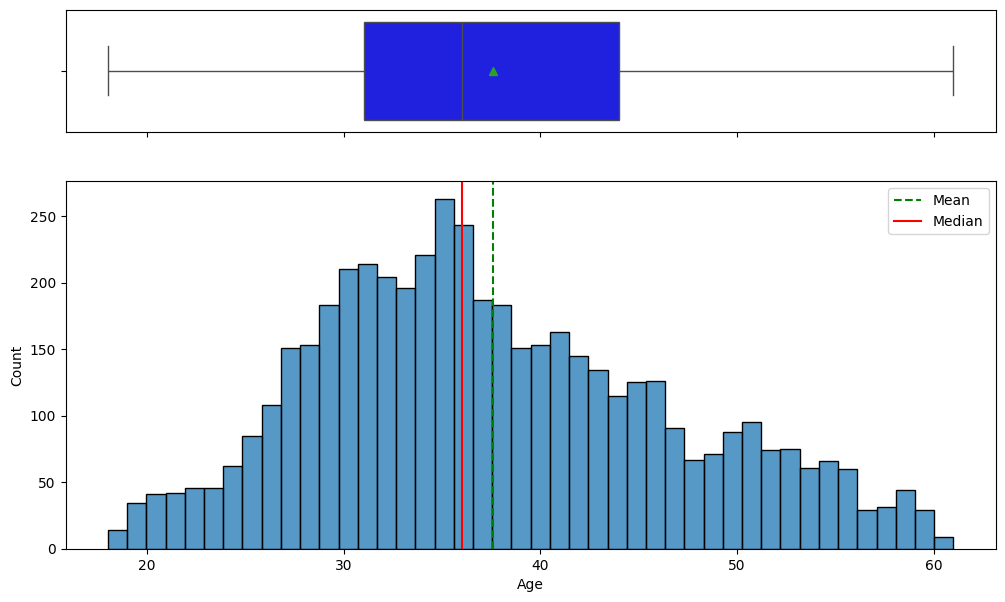

In [32]:
histogram_boxplot(tourism_copy,'Age')

In [33]:
# Age is almost distributed normally
# It is skewed right

In [34]:
print(tourism_copy['DurationOfPitch'].mean())
print(tourism_copy['DurationOfPitch'].quantile(0.25))
print(tourism_copy['DurationOfPitch'].quantile(0.75))
print(tourism_copy['MonthlyIncome'].describe())


15.443330605564649
9.0
20.0
count     4888.000000
mean     23539.350245
std       5364.619055
min       1000.000000
25%      20228.000000
50%      22217.500000
75%      25527.750000
max      98678.000000
Name: MonthlyIncome, dtype: float64


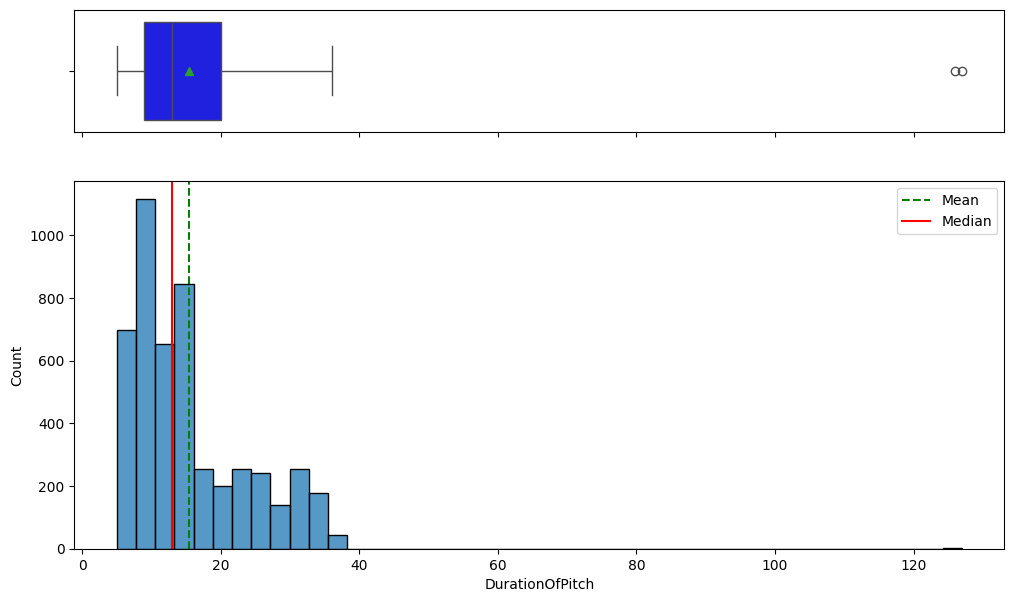

In [35]:
histogram_boxplot(tourism_copy,'DurationOfPitch')

In [36]:
# We can see some outliers
# Duration of Pitch is high for certain customer

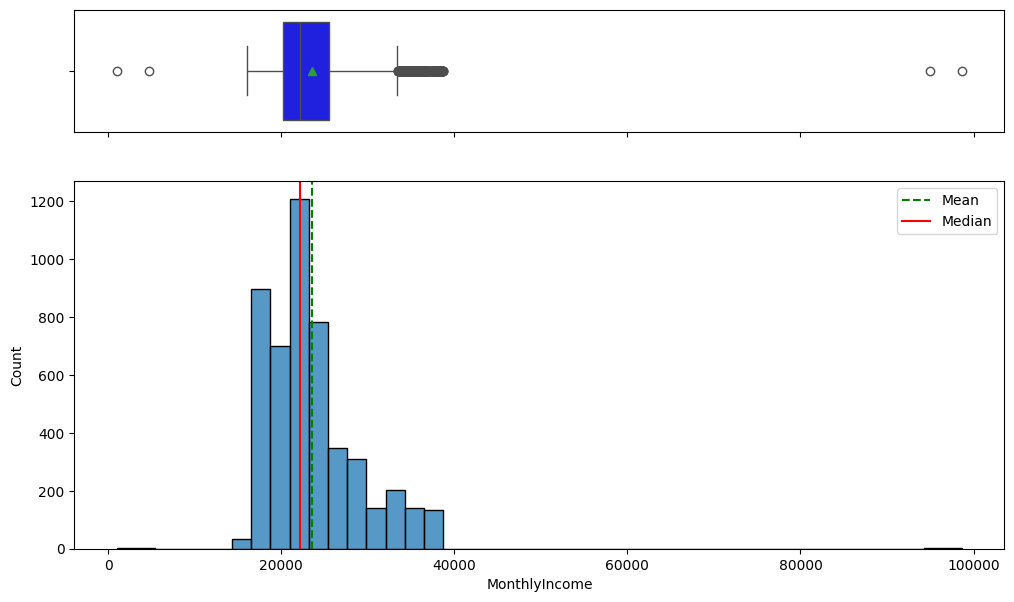

In [37]:
histogram_boxplot(tourism_copy,'MonthlyIncome')

In [38]:
#we can see outliers which means that some people has less income and some have high income

In [39]:
# for creating labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):


    total = len(data[feature])
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width()
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

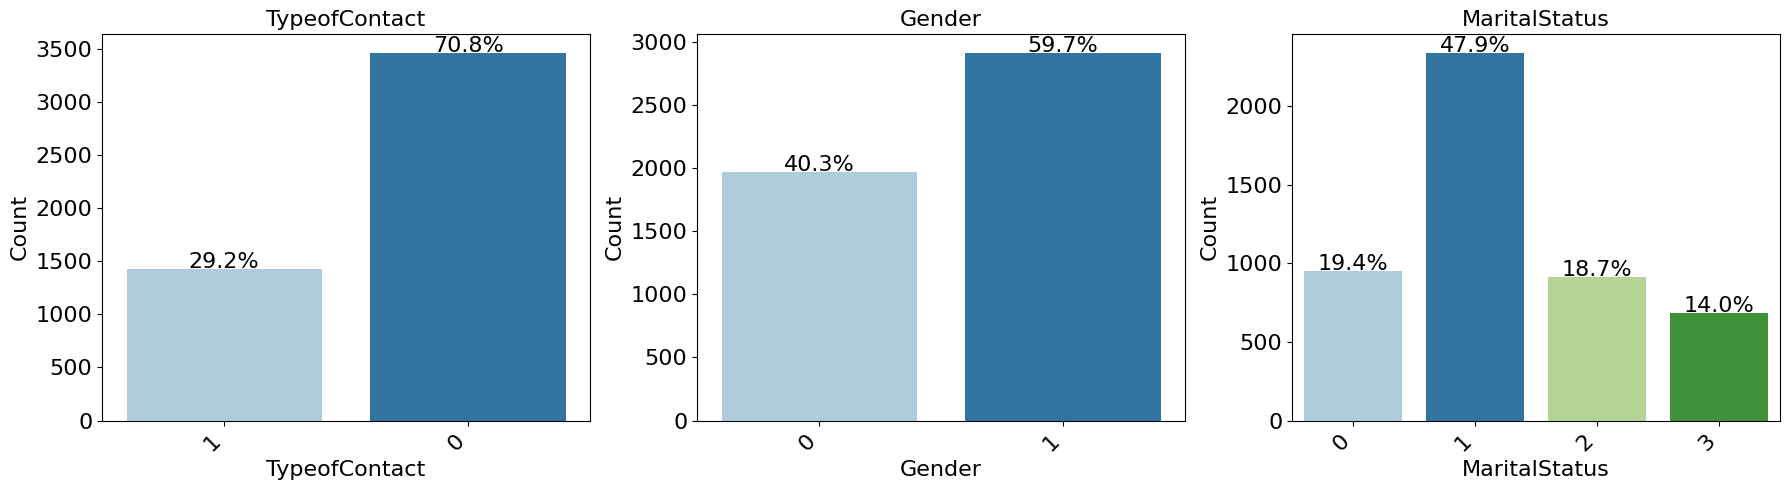

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with 3 subplots arranged horizontally
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=False)

def plot_single_category_on_ax(data, feature, ax, perc=False):
    total = len(data[feature])
    sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index.sort_values(),
        ax=ax
    )
    ax.set_title(feature, fontsize=16)
    ax.set_xlabel(feature, fontsize=16)
    ax.set_ylabel("Count", fontsize=16)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right",fontsize=16)
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=16)
    ax.tick_params(axis='x', rotation=45)

    if perc:
        for p in ax.patches:
            height = p.get_height()
            if height > 0:
                ax.annotate(
                    f'{100 * height / total:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center',
                    va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=16
                )


# Plot TypeofContact on the first subplot
plot_single_category_on_ax(tourism_copy, "TypeofContact", axes[0], perc=True)

# Plot Gender on the second subplot
plot_single_category_on_ax(tourism_copy, "Gender", axes[1], perc=True)

# Plot MaritalStatus on the third subplot
plot_single_category_on_ax(tourism_copy, "MaritalStatus", axes[2], perc=True)

plt.tight_layout()
plt.show()

In [41]:
# majority of customers are invited by company about 70 percent and only 29 percent are Self Inquiry

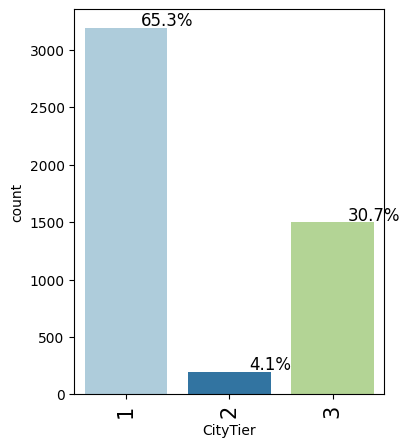

In [42]:
labeled_barplot(tourism_copy, "CityTier", perc=True)

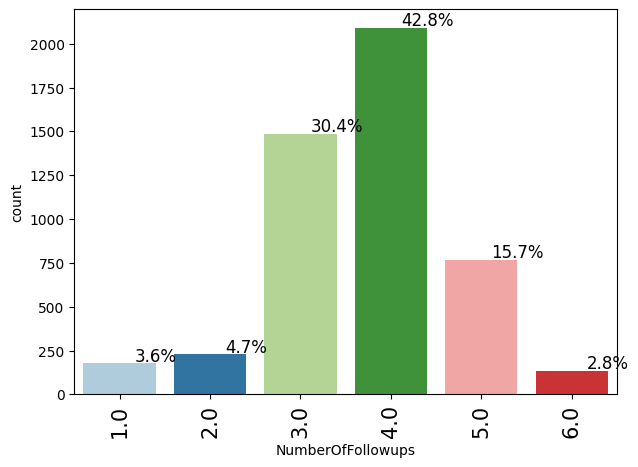

In [43]:
labeled_barplot(tourism_copy, "NumberOfFollowups", perc=True)

In [44]:
# about 42 percent customers got 4 follows and 30 percent got 3 followups

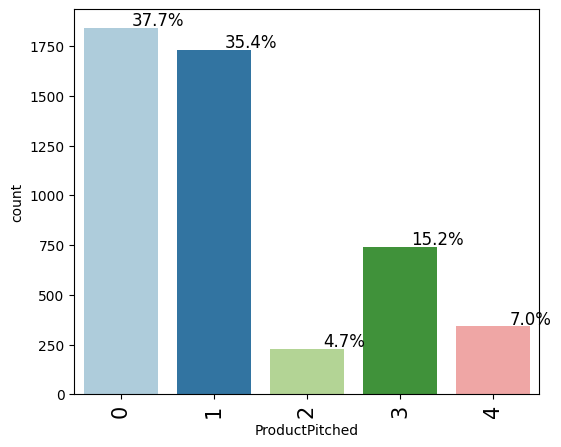

In [45]:
labeled_barplot(tourism_copy, "ProductPitched", perc=True)

In [46]:
# about 37 pecent people took basic and 35 percent took standard

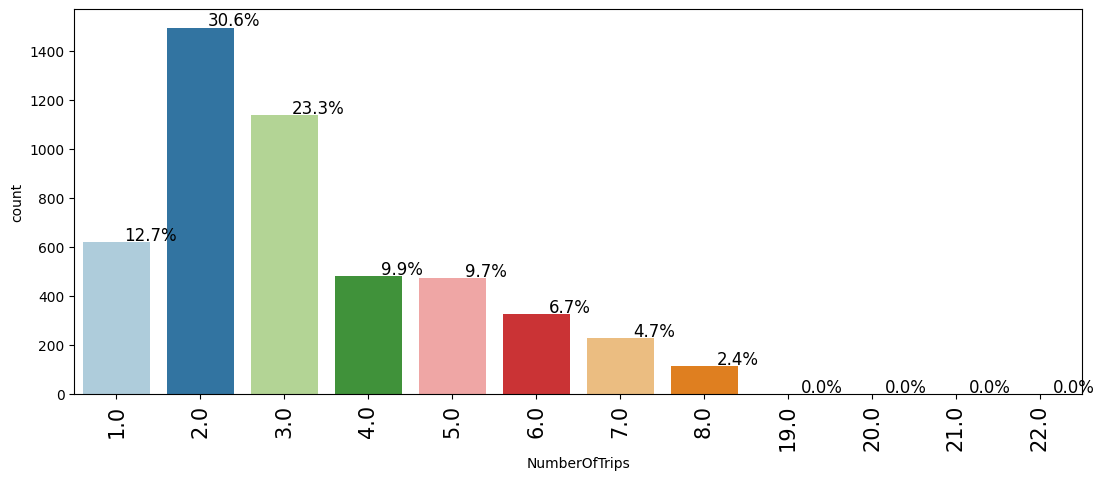

In [47]:
labeled_barplot(tourism_copy, "NumberOfTrips", perc=True)

In [48]:
# majority of customers ie 30 percent done 2 trips and 22.1 percent done 3 trips

In [49]:
# monthlyincome is highly correlated with age
# numberofchildrenvisiting is highly correlated with numberofpersonvisiting ie majority is family
# NoofPersonVisiting is correlated with NumberofFollowups

In [50]:
# function for creating stacked bar chart


def stacked_barplot(data, predictor, target):

    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 1, 5))
    plt.legend(
        loc="lower left",
        frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

ProdTaken         0    1   All
TypeofContact                 
All            3968  920  4888
0              2852  610  3462
1              1116  310  1426
------------------------------------------------------------------------------------------------------------------------


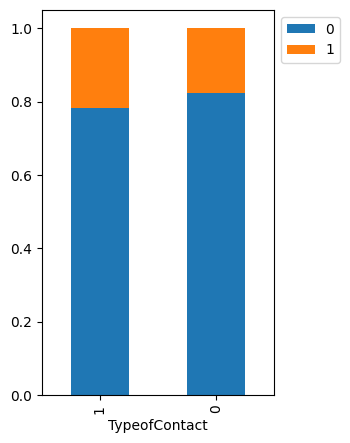

In [51]:
stacked_barplot(tourism_copy, "TypeofContact", "ProdTaken")

In [52]:
# self inquiry people taken the product that company contact.However there is not much difference

ProdTaken             0    1   All
NumberOfFollowups                 
All                3968  920  4888
4.0                1708  383  2091
3.0                1238  248  1486
5.0                 578  191   769
6.0                  82   54   136
2.0                 205   24   229
1.0                 157   20   177
------------------------------------------------------------------------------------------------------------------------


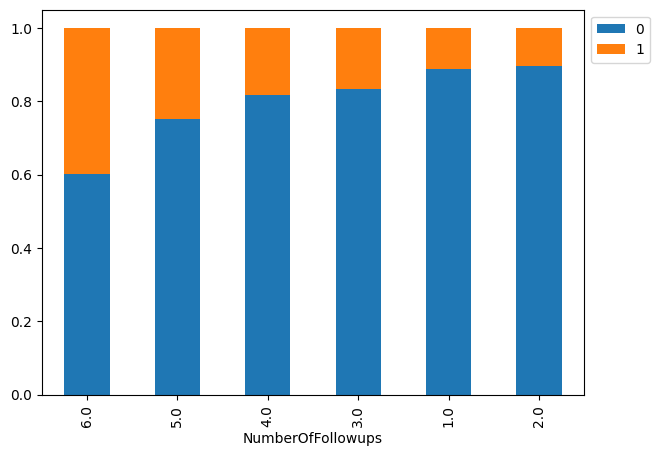

In [53]:
stacked_barplot(tourism_copy, "NumberOfFollowups", "ProdTaken")

NumberOfFollowups       1.0  2.0   3.0   4.0  5.0  6.0   All
NumberOfPersonVisiting                                      
All                     177  229  1486  2091  769  136  4888
3                        79  119   643  1061  417   83  2402
4                         0   79    25   611  258   53  1026
1                         1    1    27    10    0    0    39
2                        97   30   791   407   93    0  1418
5                         0    0     0     2    1    0     3
------------------------------------------------------------------------------------------------------------------------


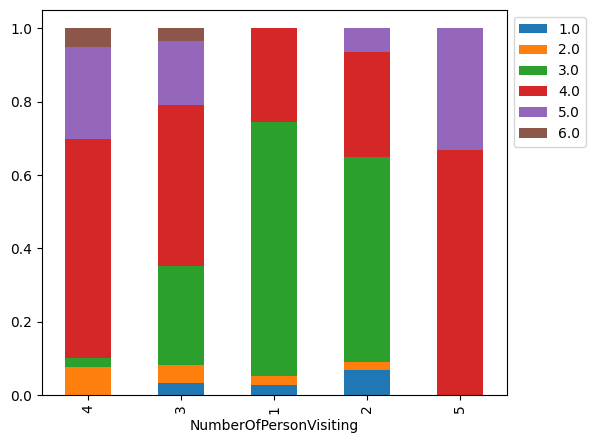

In [54]:
stacked_barplot(tourism_copy, "NumberOfPersonVisiting","NumberOfFollowups")

In [55]:
# as number of followup increases the chance of taking product is high

ProdTaken           0    1   All
DurationOfPitch                 
All              3968  920  4888
9.0               410   81   491
8.0               296   69   365
16.0              237   56   293
15.0              229   55   284
7.0               296   50   346
10.0              211   50   261
6.0               299   48   347
14.0              227   42   269
11.0              170   37   207
12.0              174   35   209
30.0               67   32    99
13.0              205   32   237
31.0               52   31    83
17.0              151   24   175
23.0               64   23    87
22.0               66   23    89
29.0               56   22    78
19.0               36   22    58
18.0               60   21    81
20.0               46   20    66
28.0               44   18    62
21.0               59   17    76
24.0               61   17    78
32.0               59   15    74
27.0               66   14    80
25.0               61   14    75
26.0               75   12    87
35.0      

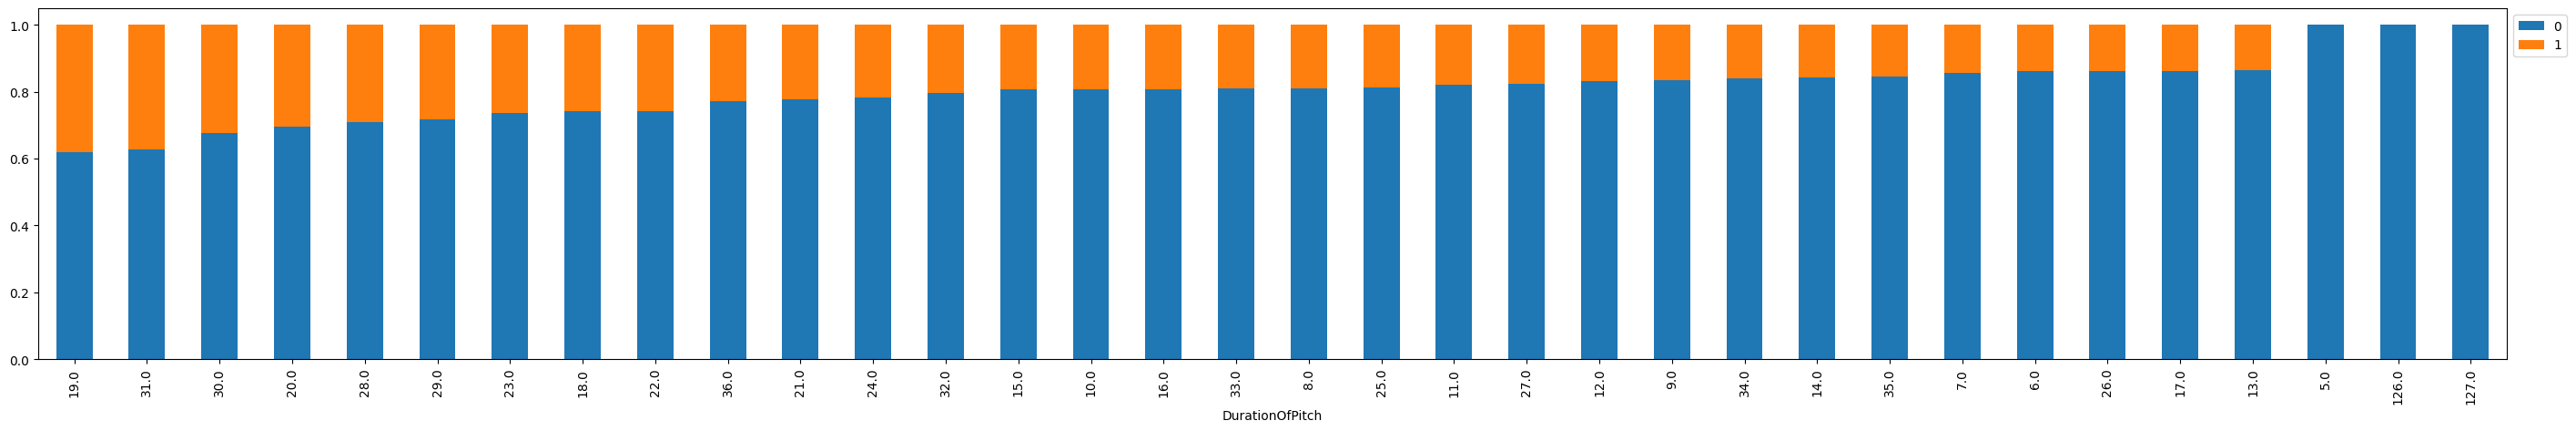

In [56]:
stacked_barplot(tourism_copy, "DurationOfPitch", "ProdTaken")

In [57]:
# as duration of pitch increases the chance of taking product is high

In [58]:
# inorder to show the relation between numberofpersonvisiting and numberoffollowps

<Axes: xlabel='NumberOfPersonVisiting', ylabel='NumberOfFollowups'>

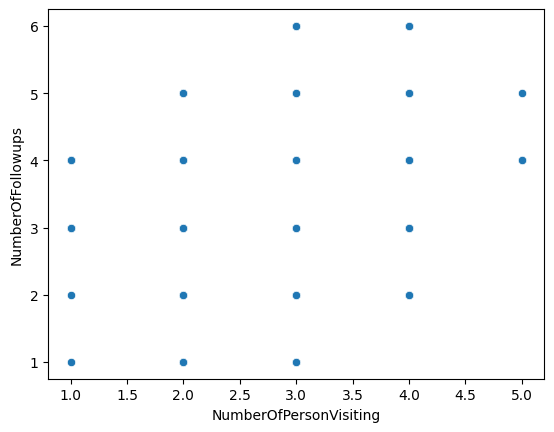

In [59]:
sns.scatterplot(data=tourism_copy, x="NumberOfPersonVisiting", y="NumberOfFollowups")

In [60]:
# to check the relation between monthlyincome and Age

<Axes: xlabel='MonthlyIncome', ylabel='Age'>

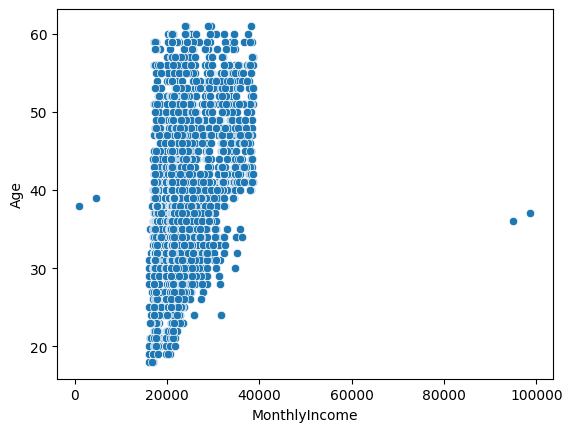

In [61]:
sns.scatterplot(data=tourism_copy, x="MonthlyIncome", y="Age")

In [62]:
X = tourism_copy.drop(['ProdTaken'],axis=1)
y = tourism_copy['ProdTaken']

In [63]:
# Splitting data into training and test set:
X_train, X_test, y_train, y_test =train_test_split(X, y, test_size=0.3, random_state=0)
print(X_train.shape, X_test.shape)

(3421, 12) (1467, 12)


Metrics on Test Set

Logistic Regression
              precision    recall  f1-score   support

           0       0.82      0.99      0.90      1195
           1       0.53      0.03      0.06       272

    accuracy                           0.82      1467
   macro avg       0.67      0.51      0.48      1467
weighted avg       0.76      0.82      0.74      1467


Decision Tree
              precision    recall  f1-score   support

           0       0.91      0.92      0.91      1195
           1       0.63      0.60      0.61       272

    accuracy                           0.86      1467
   macro avg       0.77      0.76      0.76      1467
weighted avg       0.86      0.86      0.86      1467


Random Forest
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      1195
           1       0.94      0.46      0.62       272

    accuracy                           0.89      1467
   macro avg       0.91      0.73      0.78      1467
wei

<Figure size 400x400 with 0 Axes>

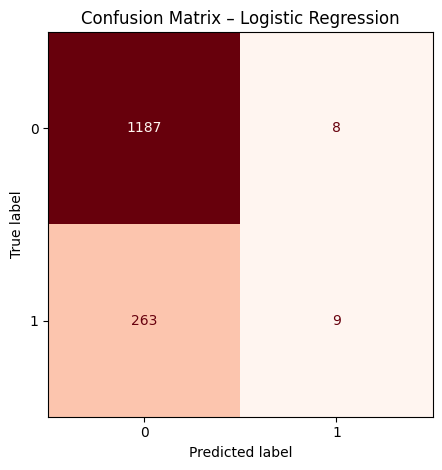

<Figure size 400x400 with 0 Axes>

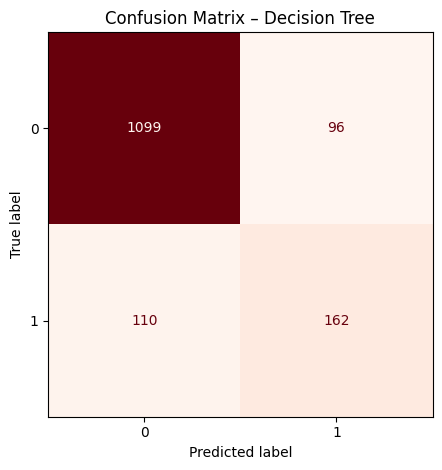

<Figure size 400x400 with 0 Axes>

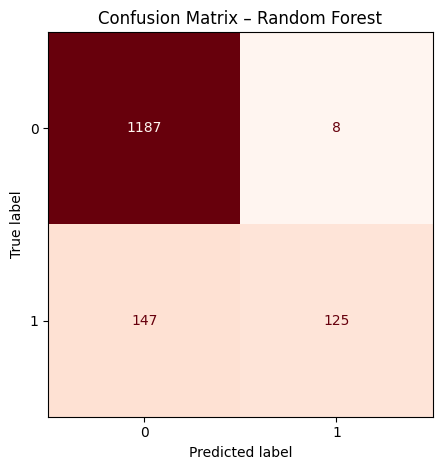

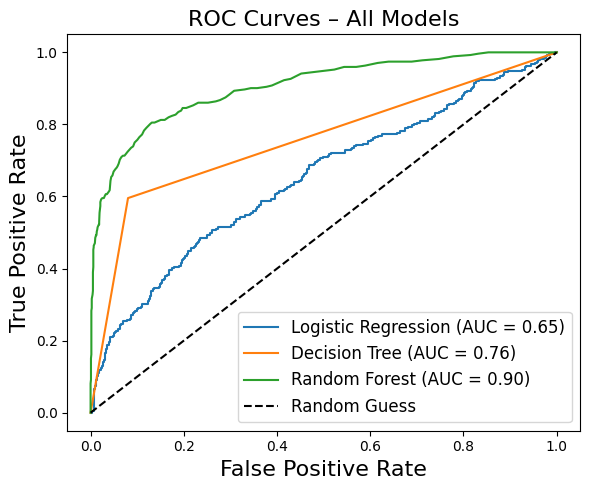

In [70]:
#  IMPORTS
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    classification_report

)


#  1. DEFINE MODELS
log_reg = LogisticRegression()
dt = DecisionTreeClassifier(criterion='gini',random_state=1)
rf = RandomForestClassifier(n_estimators=200,random_state=0)
models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dt,
    "Random Forest": rf
}

#  2. FIT MODELS
for name, model in models.items():
    model.fit(X_train, y_train)

#  3. PREDICTIONS & PROBABILITIES
y_pred = {}
y_prob = {}   # probability of class 1

for name, model in models.items():
    y_pred[name] = model.predict(X_test)
    y_prob[name] = model.predict_proba(X_test)[:, 1]


#  4. METRICS TABLE
print("Metrics on Test Set")
for name in models.keys():
    print(f"\n{name}")
    print(classification_report(y_test, y_pred[name],labels=[0,1]))


#  5. CONFUSION MATRICES
for name, model in models.items():
    cm = confusion_matrix(y_test, y_pred[name])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

    plt.figure(figsize=(4, 4))
    disp.plot(values_format='d', cmap='Reds', colorbar=False)
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

#  6. ROC CURVES
plt.figure(figsize=(6, 5))

for name in models.keys():
    fpr, tpr, _ = roc_curve(y_test, y_prob[name])
    auc = roc_auc_score(y_test, y_prob[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate", fontsize=16)
plt.ylabel("True Positive Rate", fontsize=16)
plt.title("ROC Curves – All Models", fontsize=16)
plt.legend(loc="lower right", fontsize=12)
plt.tight_layout()
plt.show()

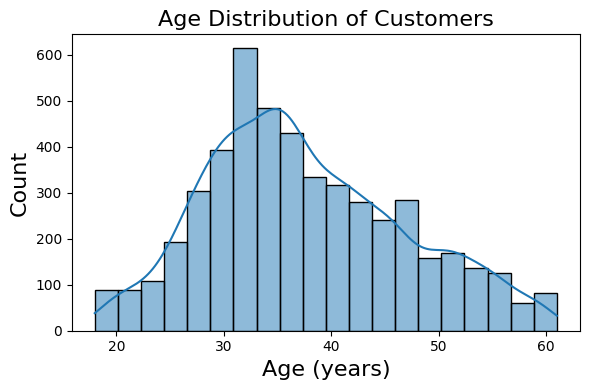

In [65]:
#Figure 1
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(tourism_copy['Age'], bins=20, kde=True)
plt.title('Age Distribution of Customers',fontsize=16)
plt.xlabel('Age (years)',fontsize=16)
plt.ylabel('Count',fontsize=16)
plt.tight_layout()
plt.show()

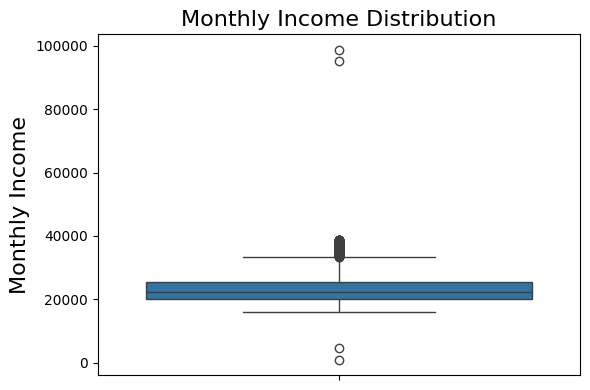

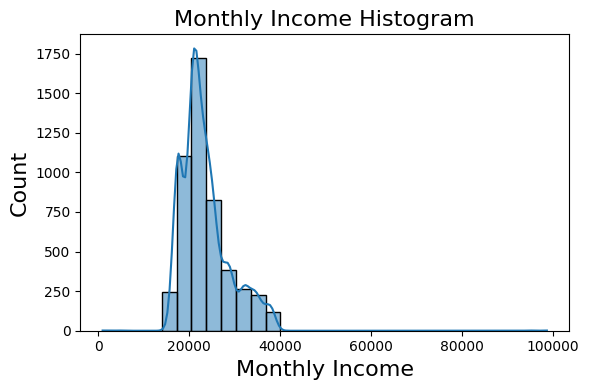

In [67]:
# Figure 3
plt.figure(figsize=(6,4))
sns.boxplot(y='MonthlyIncome', data=tourism_copy)
plt.title('Monthly Income Distribution', fontsize=16)
plt.ylabel('Monthly Income',fontsize=16)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6,4))
sns.histplot(tourism_copy['MonthlyIncome'], bins=30, kde=True)
plt.title('Monthly Income Histogram',fontsize=16)
plt.xlabel('Monthly Income',fontsize=16)
plt.ylabel('Count',fontsize=16)
plt.tight_layout()
plt.show()

Age                        -0.134659
DurationOfPitch             0.069761
NumberOfFollowups           0.111437
NumberOfTrips               0.015110
NumberOfChildrenVisiting    0.004066
MonthlyIncome              -0.121857
dtype: float64


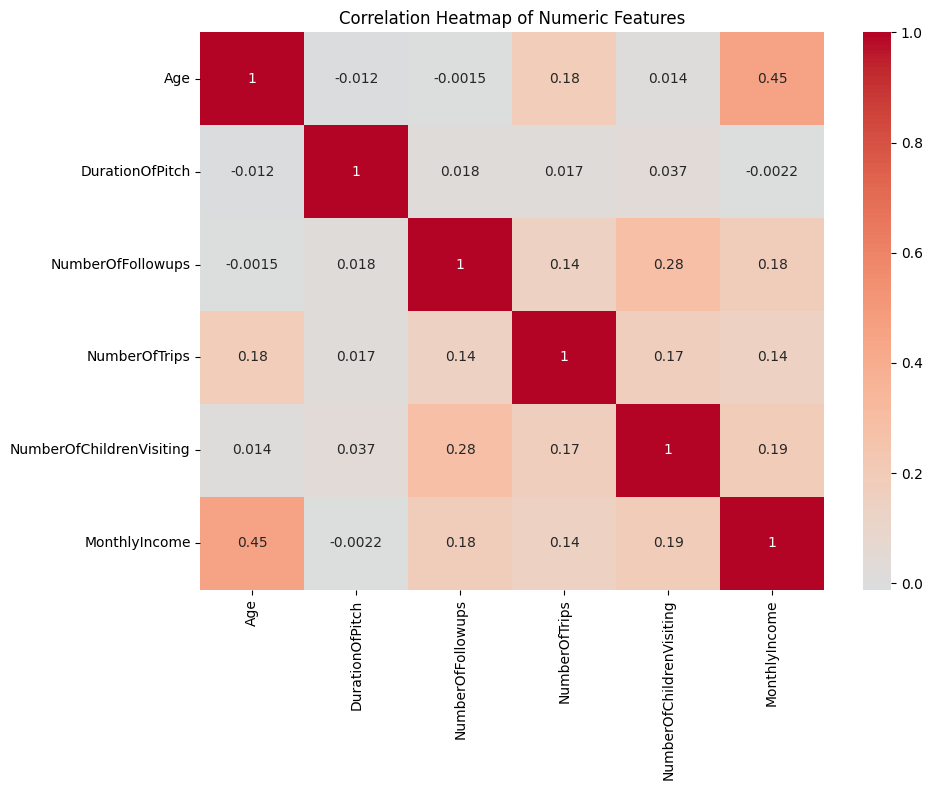

In [68]:
#Figure 5
plt.figure(figsize=(10,8))
numeric_cols = tourism_copy.select_dtypes(include=np.float64).columns
corr = tourism_copy[numeric_cols].corr(numeric_only=True)
corr1 = tourism_copy[numeric_cols].corrwith(tourism_copy['ProdTaken'])
print(corr1)
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

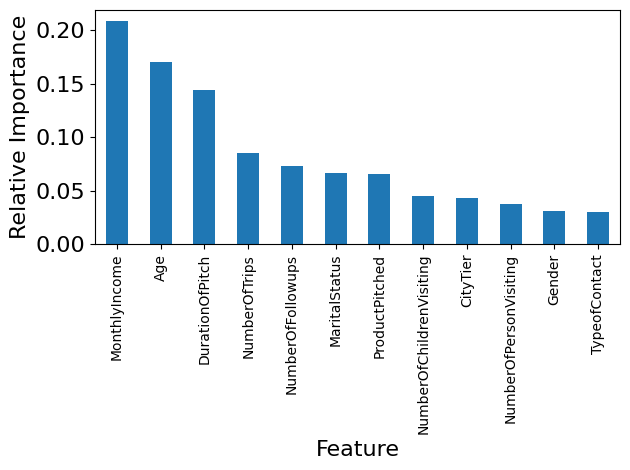

,0
MonthlyIncome,0.208456
Age,0.170017
DurationOfPitch,0.144001
NumberOfTrips,0.085400
NumberOfFollowups,0.072626
MaritalStatus,0.066618
ProductPitched,0.065777
NumberOfChildrenVisiting,0.044621
CityTier,0.043534
NumberOfPersonVisiting,0.037341


In [77]:
#F7

importances = rf.feature_importances_
feature_names = X.columns

fi_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure
fi_series.plot(kind='bar')
plt.xlabel('Feature',fontsize=16)
plt.ylabel('Relative Importance',fontsize=16)
plt.tick_params(axis='y',labelsize=16)
plt.tick_params(axis='x',labelsize=10)
plt.tight_layout()
plt.show()

fi_series